# 02 — SQL Business Analysis

## Objective
Answer seven business questions using SQL queries on the 
Northwind database. Results are loaded into Pandas DataFrames 
for visualisation.

## Contents
1. Revenue trend over time
2. Top 10 customers by revenue
3. Top and bottom products by revenue
4. Revenue by country
5. Revenue by product category
6. Top employees by sales
7. Low stock products relative to sales volume

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

conn = sqlite3.connect('../data/northwind.db')
print("Connected successfully")

Connected successfully


### Monthly Revenue Trend

In [4]:
query = """SELECT strftime('%Y-%m', OrderDate) AS Month,
SUM(Quantity * UnitPrice) AS Revenue
FROM Orders
JOIN [Order Details] ON Orders.OrderID = [Order Details].OrderID
GROUP BY Month
ORDER BY Month
"""
tables = pd.read_sql(query, conn)
print(tables)

       Month     Revenue
0    2012-07  2066219.40
1    2012-08  3556875.79
2    2012-09  3440144.98
3    2012-10  3201529.96
4    2012-11  2980494.74
..       ...         ...
131  2023-06  3071787.73
132  2023-07  3350337.36
133  2023-08  3293158.67
134  2023-09  3544698.51
135  2023-10  2923364.35

[136 rows x 2 columns]


In [5]:
tables.head()

,Month,Revenue
0,2012-07,2066219.40
1,2012-08,3556875.79
2,2012-09,3440144.98
3,2012-10,3201529.96
4,2012-11,2980494.74


Values seem slightly off from what I initially expected dates (1996-1998), doing further exploration to confirm database is just updated and not an issue with the values.

In [2]:
pd.read_sql("""
SELECT COUNT(DISTINCT Orders.OrderID) as TotalOrders,
       SUM(Quantity * UnitPrice) as TotalRevenue
FROM Orders
JOIN [Order Details] ON Orders.OrderID = [Order Details].OrderID
""", conn)

,TotalOrders,TotalRevenue
0,16282,4.484753e+08


In [6]:
pd.read_sql("SELECT OrderDate, Quantity, UnitPrice FROM Orders JOIN [Order Details] ON Orders.OrderID = [Order Details].OrderID LIMIT 5", conn)

,OrderDate,Quantity,UnitPrice
0,2016-07-04,12,14.0
1,2016-07-04,10,9.8
2,2016-07-04,5,34.8
3,2016-07-05,9,18.6
4,2016-07-05,40,42.4


## Data Note
This SQLite version of Northwind contains 16,282 orders 
(vs 830 in the original Access database) with updated dates 
starting from 2012. Values are consistent and analysis 
proceeds normally.

In [7]:
monthly_revenue = pd.read_sql(query, conn)
monthly_revenue.head()

,Month,Revenue
0,2012-07,2066219.40
1,2012-08,3556875.79
2,2012-09,3440144.98
3,2012-10,3201529.96
4,2012-11,2980494.74


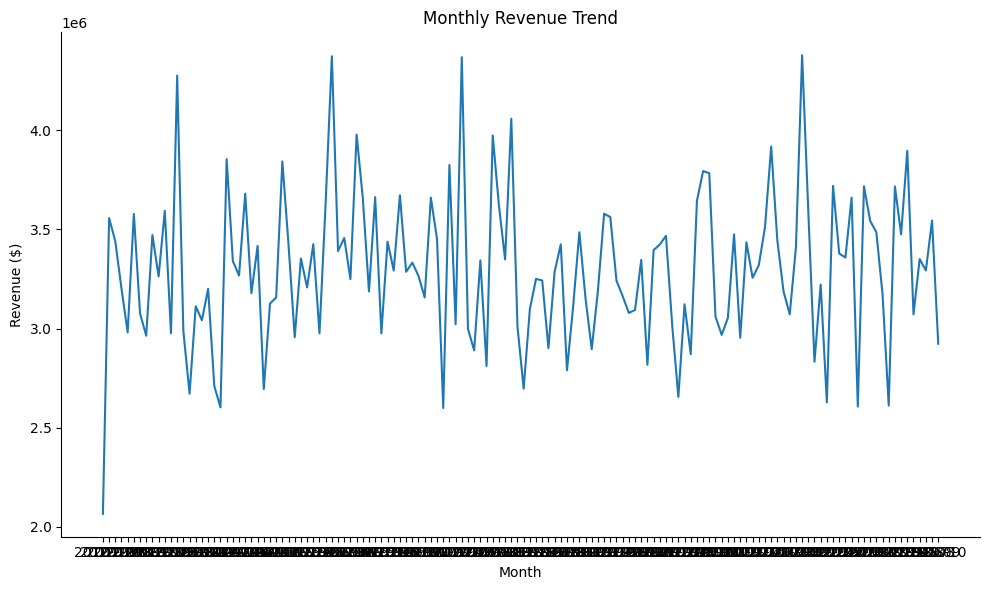

In [11]:
fig,ax = plt.subplots(figsize=(10,6))

ax.plot(monthly_revenue['Month'],monthly_revenue['Revenue'])
ax.set_title('Monthly Revenue Trend')
ax.set_xlabel('Month')
ax.set_ylabel('Revenue ($)')
    
# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../images/monthly_revenue_trend.png', dpi=150)
plt.show()


Scale and month display is not ideal. Will try dividing into years instead.

In [12]:
query = """
SELECT strftime('%Y', OrderDate) AS Year,
       SUM(Quantity * UnitPrice) AS Revenue
FROM Orders
JOIN [Order Details] ON Orders.OrderID = [Order Details].OrderID
GROUP BY Year
ORDER BY Year
"""
yearly_revenue = pd.read_sql(query, conn)
yearly_revenue.head()

,Year,Revenue
0,2012,18823201.72
1,2013,38633120.01
2,2014,38870148.13
3,2015,41423456.72
4,2016,40586886.89


In [13]:
yearly_revenue['Revenue_M'] = yearly_revenue['Revenue'] / 1_000_000

In [14]:
yearly_revenue.head()

,Year,Revenue,Revenue_M
0,2012,18823201.72,18.823202
1,2013,38633120.01,38.633120
2,2014,38870148.13,38.870148
3,2015,41423456.72,41.423457
4,2016,40586886.89,40.586887


In [15]:
pd.read_sql("SELECT MIN(OrderDate), MAX(OrderDate) FROM Orders", conn)

,MIN(OrderDate),MAX(OrderDate)
0,2012-07-10 15:40:46,2023-10-28 00:09:48


Looks like 2012and 2023 is a partial year and might skew the visual when viewing or be misleading. For now will be filtered out.

In [20]:
query = """
SELECT strftime('%Y', OrderDate) AS Year,
       SUM(Quantity * UnitPrice) AS Revenue
FROM Orders
JOIN [Order Details] ON Orders.OrderID = [Order Details].OrderID
WHERE strftime('%Y', OrderDate) NOT IN ('2012', '2023')
GROUP BY Year
ORDER BY Year
"""
yearly_revenue = pd.read_sql(query, conn)
yearly_revenue.head()

,Year,Revenue
0,2013,38633120.01
1,2014,38870148.13
2,2015,41423456.72
3,2016,40586886.89
4,2017,40251207.78


In [21]:
yearly_revenue['Revenue_M'] = yearly_revenue['Revenue'] / 1_000_000
yearly_revenue.head()

,Year,Revenue,Revenue_M
0,2013,38633120.01,38.633120
1,2014,38870148.13,38.870148
2,2015,41423456.72,41.423457
3,2016,40586886.89,40.586887
4,2017,40251207.78,40.251208


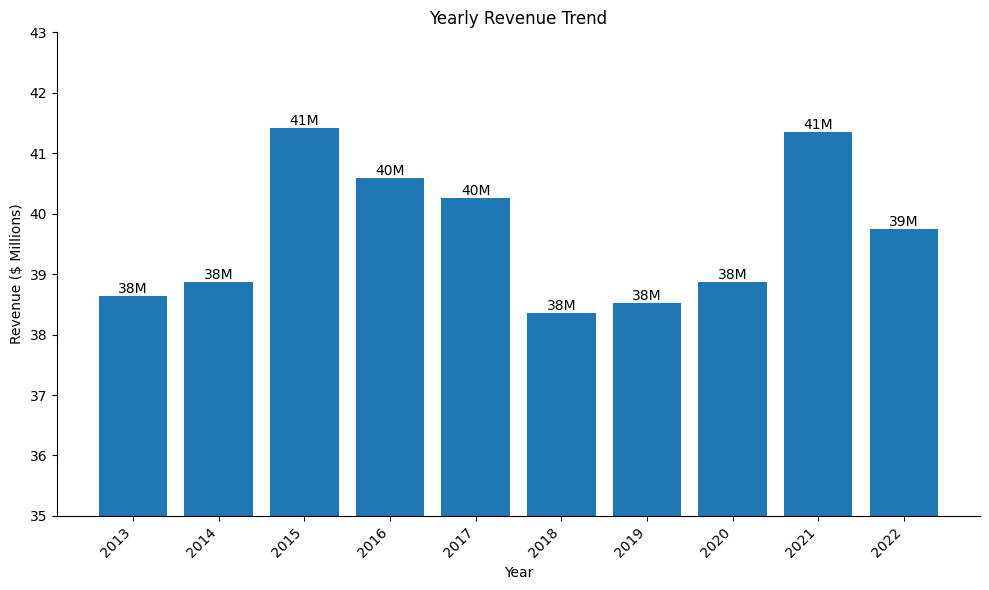

In [30]:
fig,ax = plt.subplots(figsize=(10,6))

ax.bar(yearly_revenue['Year'],yearly_revenue['Revenue_M'])
ax.set_title('Yearly Revenue Trend')
ax.set_xlabel('Year')
ax.set_ylabel('Revenue ($ Millions)')

# Add value labels on top of each bar
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2, 
            bar.get_height(),
            str(int(bar.get_height())) + 'M',
            ha='center', va='bottom', fontsize=10)
    
# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.xticks(rotation = 45, ha='right')
ax.set_ylim(35, 43)
plt.tight_layout()
plt.savefig('../images/yearly_revenue_trend.png', dpi=150)
plt.show()


## Q1 — Yearly Revenue Trend
Revenue has remained relatively stable between $38M-$41M per year 
from 2013 to 2022, with slight peaks in 2015 and 2021. No significant 
growth or decline trend is visible, suggesting the business has reached 
a revenue plateau.

In [ ]:
query = """
SELECT Customers.ContactName,Customers.CustomerID,
       SUM(Quantity * UnitPrice) AS Revenue
FROM Orders
JOIN [Order Details] ON Orders.OrderID = [Order Details].OrderID
JOIN Customers ON Orders.CustomerID = Customers.CustomerID
GROUP BY Customers.CustomerID
ORDER BY Revenue DESC
LIMIT 10
"""
revenue_per_customer = pd.read_sql(query, conn)
revenue_per_customer

,ContactName,CustomerID,Revenue
0,Victoria Ashworth,BSBEV,6154115.34
1,Yoshi Latimer,HUNGC,5698023.67
2,Sergio Gutiérrez,RANCH,5559110.08
3,André Fonseca,GOURL,5552597.90
4,Ana Trujillo,ANATR,5534356.65
5,Janete Limeira,RICAR,5524990.91
6,Martine Rancé,FOLIG,5505502.85
7,Jaime Yorres,LETSS,5462611.57
8,Carlos González,LILAS,5439186.80
9,Isabel de Castro,PRINI,5437042.71


In [12]:
revenue_per_customer['Revenue_M'] = revenue_per_customer['Revenue'] / 1_000_000
revenue_per_customer.head()

,ContactName,CustomerID,Revenue,Revenue_M
0,Victoria Ashworth,BSBEV,6154115.34,6.154115
1,Yoshi Latimer,HUNGC,5698023.67,5.698024
2,Sergio Gutiérrez,RANCH,5559110.08,5.559110
3,André Fonseca,GOURL,5552597.90,5.552598
4,Ana Trujillo,ANATR,5534356.65,5.534357


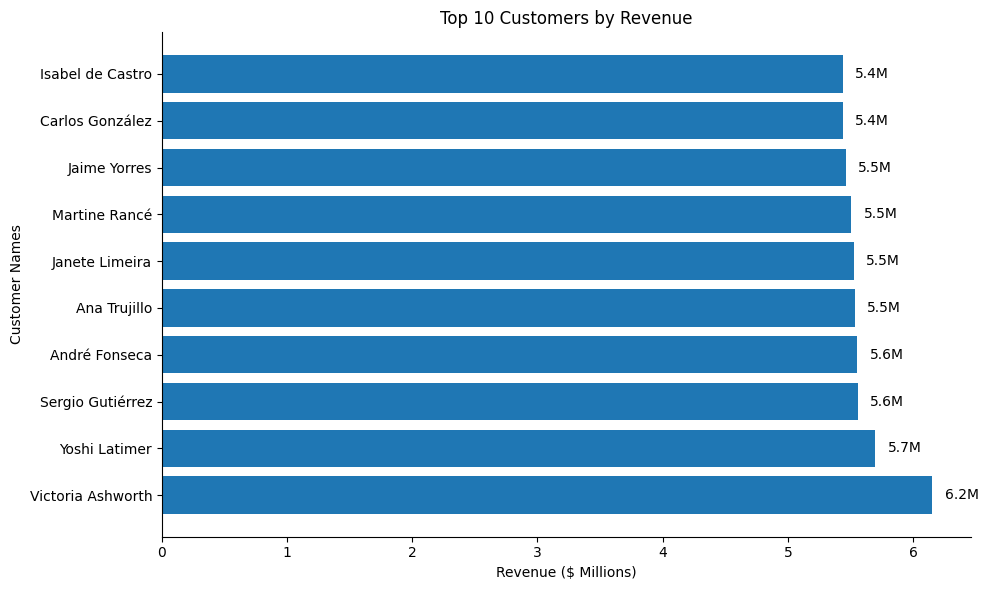

In [20]:
fig,ax = plt.subplots(figsize=(10,6))

ax.barh(revenue_per_customer['ContactName'],revenue_per_customer['Revenue_M'])
ax.set_title('Top 10 Customers by Revenue')
ax.set_xlabel('Revenue ($ Millions)')
ax.set_ylabel('Customer Names')

for bar in ax.patches:
    ax.text(bar.get_width() + 0.1,
        bar.get_y() + bar.get_height()/2,
        str(round(bar.get_width(), 1)) + 'M',
        ha='left', va='center', fontsize=10)
    
# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../images/top_10_customers.png', dpi=150)
plt.show()

## Q2 - Top 10 Customers by Revenue
The top 10 customers generate between $5.4M and $6.2M each, with Victoeria Ashworth leading at $6.2M. However, the narrow revenue range indicates that no single customer dominates the company revenue, reducing concentration risks.

In [ ]:
query = """
SELECT Products.ProductID,Products.ProductName,
       SUM([Order Details].Quantity * [Order Details].UnitPrice) AS Revenue
FROM Products
JOIN [Order Details] ON Products.ProductID = [Order Details].ProductID
GROUP BY Products.ProductID
ORDER BY Revenue
"""
revenue_per_product = pd.read_sql(query, conn)
top_products = revenue_per_product.head(5)
bottom_products = revenue_per_product.tail(5).reset_index().drop(columns=['index'])

In [31]:
top_products

,ProductID,ProductName,Revenue
0,33,Geitost,507186.00
1,24,Guaraná Fantástica,908535.60
2,13,Konbu,1214882.40
3,52,Filo Mix,1421520.80
4,54,Tourtière,1509521.85


In [34]:
bottom_products

,ProductID,ProductName,Revenue
0,18,Carnarvon Tigers,12607487.50
1,20,Sir Rodney's Marmalade,16654879.80
2,9,Mishi Kobe Niku,19424638.00
3,29,Thüringer Rostbratwurst,24630836.96
4,38,Côte de Blaye,53274482.70
